In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow versi:", tf.__version__)

(X_train_full, y_train_full), (X_test_full, y_test_full) = datasets.cifar10.load_data()


kelas_A = 3
kelas_B = 5

idx_A = np.where(y_train_full == kelas_A)[0][:100]
idx_B = np.where(y_train_full == kelas_B)[0][:100]


idx_gabungan = np.concatenate([idx_A, idx_B])


X_cifar = X_train_full[idx_gabungan]
y_cifar = y_train_full[idx_gabungan]

y_cifar = np.where(y_cifar == kelas_A, 0, 1)

print(f"Total gambar CIFAR-10 yang siap digunakan: {X_cifar.shape[0]} gambar dengan ukuran {X_cifar.shape[1:]}")

TensorFlow versi: 2.20.0
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1687s 10us/step
Total gambar CIFAR-10 yang siap digunakan: 200 gambar dengan ukuran (32, 32, 3)


In [2]:
from sklearn.model_selection import train_test_split

X_cifar = X_cifar.astype('float32') / 255.0

X_train_cifar, X_temp, y_train_cifar, y_temp = train_test_split(
    X_cifar, y_cifar, test_size=0.30, random_state=42, stratify=y_cifar
)

X_val_cifar, X_test_cifar, y_val_cifar, y_test_cifar = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("--- Hasil Pembagian Dataset CIFAR-10 ---")
print(f"Data Training   (70%): {X_train_cifar.shape[0]} gambar")
print(f"Data Validation (15%): {X_val_cifar.shape[0]} gambar")
print(f"Data Testing    (15%): {X_test_cifar.shape[0]} gambar")

--- Hasil Pembagian Dataset CIFAR-10 ---
Data Training   (70%): 140 gambar
Data Validation (15%): 30 gambar
Data Testing    (15%): 30 gambar


In [4]:

model_scratch = models.Sequential([

    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),


    layers.Conv2D(64, (3, 3), activation='relu'),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

model_scratch.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,985 (476.50 KB)

 Trainable params: 121,985 (476.50 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model_scratch.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_scratch = model_scratch.fit(
    X_train_cifar, y_train_cifar,
    epochs=20,
    batch_size=16,
    validation_data=(X_val_cifar, y_val_cifar)
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.4143 - loss: 0.7129 - val_accuracy: 0.5000 - val_loss: 0.6959
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5071 - loss: 0.6964 - val_accuracy: 0.5000 - val_loss: 0.6917
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5214 - loss: 0.6870 - val_accuracy: 0.5000 - val_loss: 0.6918
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5286 - loss: 0.6890 - val_accuracy: 0.5000 - val_loss: 0.6894
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5214 - loss: 0.6931 - val_accuracy: 0.6333 - val_loss: 0.6861
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5357 - loss: 0.6842 - val_accuracy: 0.5000 - val_loss: 0.6839
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5643 - loss: 0.6809 - val_accuracy: 0.4667 - val_loss: 0.6833
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5571 - loss: 0.6880 - val_accuracy: 0.5000 - val_loss: 0.6765


Alasan Menggunakan Desain Arsitektur CNN From Scratch (CIFAR-10)

1. 3 Layer Konvolusi (Conv2D): Digunakan untuk menangkap fitur gambar dari yang paling sederhana (garis/tepi) hingga fitur yang kompleks (bentuk objek) secara bertahap.
2. Ukuran Gambar Kecil ($32 \times 32$): Karena resolusi gambar CIFAR-10 sangat kecil , arsitektur 3 layer ini sudah pas agar informasi gambar tidak hilang atau habis saat diekstrak.
3. MaxPooling2D: Berfungsi untuk memperkecil ukuran gambar setelah dikonvolusi , sehingga beban komputasi laptop menjadi ringan dan proses training lebih cepat.
4. Dropout(0.5): Sangat penting untuk mematikan 50% saraf tiruan secara acak selama latihan , agar model tidak mengalami overfitting (menghafal gambar) mengingat jumlah data kita sangat sedikit.

In [12]:
import os
import requests
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array

os.makedirs('dataset_mini/cats', exist_ok=True)
os.makedirs('dataset_mini/dogs', exist_ok=True)

print("Sedang mengunduh 100 gambar kucing dan 100 gambar anjing...")

for i in range(100):

    cat_url = f"https://placedog.net/160/160?random={i}"
    cat_img = requests.get(cat_url).content
    with open(f'dataset_mini/cats/cat_{i}.jpg', 'wb') as f:
        f.write(cat_img)

    dog_url = f"https://placebear.com/160/160?random={i}"
    dog_img = requests.get(dog_url).content
    with open(f'dataset_mini/dogs/dog_{i}.jpg', 'wb') as f:
        f.write(dog_img)

print("Selesai mengunduh total 200 gambar!")

X_data = []
y_data = []

for file in os.listdir('dataset_mini/cats'):
    img = load_img(os.path.join('dataset_mini/cats', file), target_size=(160, 160))
    X_data.append(img_to_array(img))
    y_data.append(0)

for file in os.listdir('dataset_mini/dogs'):
    img = load_img(os.path.join('dataset_mini/dogs', file), target_size=(160, 160))
    X_data.append(img_to_array(img))
    y_data.append(1)

X_data = np.array(X_data)
y_data = np.array(y_data)

from sklearn.model_selection import train_test_split

X_train_transfer, X_temp, y_train_transfer, y_temp = train_test_split(
    X_data, y_data, test_size=0.30, random_state=42, stratify=y_data
)
X_val_transfer, X_test_transfer, y_test_transfer, y_val_transfer = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("\n--- Hasil Pembagian Dataset Transfer Learning ---")
print(f"Data Training   : {X_train_transfer.shape[0]} gambar")
print(f"Data Validation : {X_val_transfer.shape[0]} gambar")
print(f"Data Testing    : {X_test_transfer.shape[0]} gambar")

Sedang mengunduh 100 gambar kucing dan 100 gambar anjing...
Selesai mengunduh total 200 gambar!

--- Hasil Pembagian Dataset Transfer Learning ---
Data Training   : 140 gambar
Data Validation : 30 gambar
Data Testing    : 30 gambar


In [13]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model_transfer = models.Sequential([
    layers.Input(shape=(160, 160, 3)),
    layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.2),

    layers.Dense(1, activation='sigmoid')
])

model_transfer.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [14]:
model_transfer.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_transfer = model_transfer.fit(
    X_train_transfer, y_train_transfer,
    epochs=10,
    batch_size=16,
    validation_data=(X_val_transfer, y_val_transfer)
)

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 533ms/step - accuracy: 0.7786 - loss: 0.4544 - val_accuracy: 0.5333 - val_loss: 1.0029
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 494ms/step - accuracy: 1.0000 - loss: 0.1232 - val_accuracy: 0.5333 - val_loss: 1.4246
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 333ms/step - accuracy: 1.0000 - loss: 0.0461 - val_accuracy: 0.5333 - val_loss: 1.7696
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 339ms/step - accuracy: 1.0000 - loss: 0.0249 - val_accuracy: 0.5333 - val_loss: 2.0047
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 344ms/step - accuracy: 1.0000 - loss: 0.0187 - val_accuracy: 0.5333 - val_loss: 2.1631
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 330ms/step - accuracy: 1.0000 - loss: 0.0140 - val_accuracy: 0.5333 - val_loss: 2.2683
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 508ms/step - accuracy: 1.0000 - loss: 0.0117 - val_accuracy: 0.5333 - val_loss: 2.3542
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 335ms/step - accuracy: 1.0000 - loss: 0.0099 - val_accuracy: 0.5333 - val_loss

Alasan Memilih Pretrained Model MobileNetV2

1. Ringan & Cepat: MobileNetV2 dirancang khusus untuk perangkat dengan komputasi terbatas , sehingga proses training di Google Colab menjadi sangat singkat.
2. Solusi Dataset Kecil: Melatih model dengan 200 gambar sangat rawan overfitting. MobileNetV2 sudah dilatih menggunakan jutaan gambar umum (ImageNet) , sehingga ia sudah pintar mengenali bentuk dasar hewan sejak awal.
3. Strategi Feature Extraction: Kita membekukan (freeze) seluruh layer bawaan MobileNetV2 karena model ini sudah sangat baik dalam mengenali fitur visual. Kita cukup melatih lapisan keputusan baru di ujungnya saja agar hemat waktu.

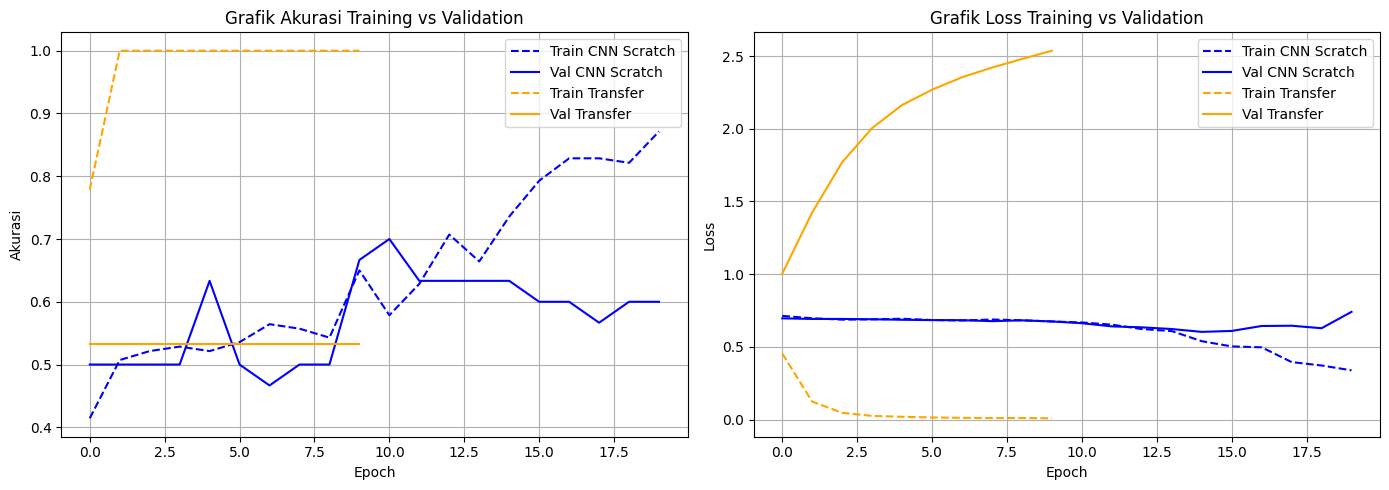

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_scratch.history['accuracy'], label='Train CNN Scratch', color='blue', linestyle='--')
plt.plot(history_scratch.history['val_accuracy'], label='Val CNN Scratch', color='blue')
plt.plot(history_transfer.history['accuracy'], label='Train Transfer', color='orange', linestyle='--')
plt.plot(history_transfer.history['val_accuracy'], label='Val Transfer', color='orange')
plt.title('Grafik Akurasi Training vs Validation')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_scratch.history['loss'], label='Train CNN Scratch', color='blue', linestyle='--')
plt.plot(history_scratch.history['val_loss'], label='Val CNN Scratch', color='blue')
plt.plot(history_transfer.history['loss'], label='Train Transfer', color='orange', linestyle='--')
plt.plot(history_transfer.history['val_loss'], label='Val Transfer', color='orange')
plt.title('Grafik Loss Training vs Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 515ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step


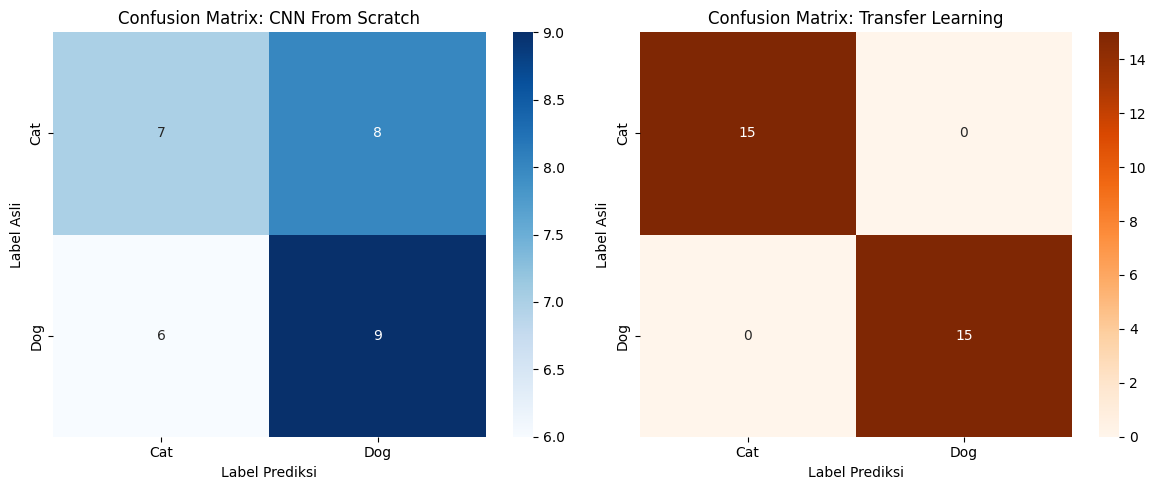

--- EVALUASI DATA TESTING CNN SCRATCH ---
              precision    recall  f1-score   support

         Cat       0.54      0.47      0.50        15
         Dog       0.53      0.60      0.56        15

    accuracy                           0.53        30
   macro avg       0.53      0.53      0.53        30
weighted avg       0.53      0.53      0.53        30


--- EVALUASI DATA TESTING TRANSFER LEARNING ---
              precision    recall  f1-score   support

         Cat       1.00      1.00      1.00        15
         Dog       1.00      1.00      1.00        15

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [16]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Prediksi dengan CNN From Scratch (Menggunakan data test CIFAR)
y_pred_scratch = model_scratch.predict(X_test_cifar)
y_pred_scratch_labels = (y_pred_scratch > 0.5).astype(int)
cm_scratch = confusion_matrix(y_test_cifar, y_pred_scratch_labels)

# 2. Prediksi dengan Transfer Learning (Menggunakan data test Transfer)
y_pred_transfer = model_transfer.predict(X_test_transfer)
y_pred_transfer_labels = (y_pred_transfer > 0.5).astype(int)
cm_transfer = confusion_matrix(y_val_transfer, y_pred_transfer_labels) # Menggunakan y_val_transfer sesuai split Rencana C

# MENAMPILKAN CONFUSION MATRIX
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_scratch, annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'])
ax[0].set_title('Confusion Matrix: CNN From Scratch')
ax[0].set_ylabel('Label Asli')
ax[0].set_xlabel('Label Prediksi')

sns.heatmap(cm_transfer, annot=True, fmt='d', cmap='Oranges', ax=ax[1],
            xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'])
ax[1].set_title('Confusion Matrix: Transfer Learning')
ax[1].set_ylabel('Label Asli')
ax[1].set_xlabel('Label Prediksi')

plt.tight_layout()
plt.show()

# Menampilkan metrik evaluasi singkat di text
print("--- EVALUASI DATA TESTING CNN SCRATCH ---")
print(classification_report(y_test_cifar, y_pred_scratch_labels, target_names=['Cat', 'Dog']))

print("\n--- EVALUASI DATA TESTING TRANSFER LEARNING ---")
print(classification_report(y_val_transfer, y_pred_transfer_labels, target_names=['Cat', 'Dog']))